# Week 8 assignment: NLP on social media data

Take our social media we collected last week and:

- extract the sentiment scores of the titles of the posts
    - you can use the keyword method, Python packages, or other methods to extract the sentiment scores
- plot a histogram of the sentiment scores
- look at descriptive statistics (mean, median, standard deviation) of the sentiment scores
- examine the text for some of the highest and lowest sentiment scores
- write a short analysis of the results and our process, as well as propose one idea for something we could use this data for

Optional advanced challenges:
- Compare different sentiment analysis methods (e.g. textblob and VADER). Does one seem to work better than another?
- Get the sentiments of the comments for each post. We can do a lot with this, such as:
    - look at the average sentiment for each post and compare it with the sentiment of the title and/or text
    - look at the distribution of sentiments for each post and find the posts with the widest range of sentiments (controversial posts)
- Examine the subjectivity of our data (e.g. using textblob)
- Use topic modeling on the posts
    - you can also add in the comments to the topic model
- Look at the most frequent words for positive and negative sentiment posts

Note: There is no assignment solution file for this week.

# Required Work

In [98]:
#Downloading certain modules.

#!conda install -c conda-forge spacy
#!python -m spacy download en_core_web_sm
#!conda install -c conda-forge textblob vadersentiment -y

In [99]:
#Importing our SQL databases from last week and converting them to dataframes.

import pandas as pd
import sqlite3

#Get SQL databases
nba = sqlite3.connect('nba_reddit.sqlite')
nba_com = sqlite3.connect('nba_reddit_comments.sqlite')

#Convert databases into dataframes
df = pd.read_sql_query('SELECT * from posts;', nba)
df_com = pd.read_sql_query('SELECT * from posts;', nba_com)

In [100]:
'''
Here we read in an example text with sentiment scores for a lot of words.
We will use these scores to process our data.
'''

sentiment_df = pd.read_csv('AFINN-en-165.txt', sep='\t', names=['word', 'score'], index_col='word')
sentiment_df

,score
word,
abandon,-2
abandoned,-2
abandons,-2
abducted,-2
abduction,-2
...,...
yucky,-2
yummy,3
zealot,-2


In [101]:
#Converting our series to a dictionary.
sentiment_dict = sentiment_df.to_dict()['score']
sentiment_dict

{'abandon': -2,
 'abandoned': -2,
 'abandons': -2,
 'abducted': -2,
 'abduction': -2,
 'abductions': -2,
 'abhor': -3,
 'abhorred': -3,
 'abhorrent': -3,
 'abhors': -3,
 'abilities': 2,
 'ability': 2,
 'aboard': 1,
 'aborted': -1,
 'aborts': -1,
 'absentee': -1,
 'absentees': -1,
 'absolve': 2,
 'absolved': 2,
 'absolves': 2,
 'absolving': 2,
 'absorbed': 1,
 'abuse': -3,
 'abused': -3,
 'abuses': -3,
 'abusing': -3,
 'abusive': -3,
 'accept': 1,
 'acceptable': 1,
 'acceptance': 1,
 'accepted': 1,
 'accepting': 1,
 'accepts': 1,
 'accessible': 1,
 'accident': -2,
 'accidental': -2,
 'accidentally': -2,
 'accidents': -2,
 'acclaim': 2,
 'acclaimed': 2,
 'accolade': 2,
 'accomplish': 2,
 'accomplished': 2,
 'accomplishes': 2,
 'accomplishment': 2,
 'accomplishments': 2,
 'accusation': -2,
 'accusations': -2,
 'accuse': -2,
 'accused': -2,
 'accuses': -2,
 'accusing': -2,
 'ache': -2,
 'achievable': 1,
 'aching': -2,
 'acquit': 2,
 'acquits': 2,
 'acquitted': 2,
 'acquitting': 2,
 'acrimo

In [102]:
'''
Here we create a function to convert a dataframe column
into a list of sentiment scores.  We will use this to add that list
onto the end of the dataframe as a column of scores where each score
lines up with the post's title.
'''

import numpy as np

def get_sentiment(df):
    title_sentiments = []
    for title in df['title']:

        #Converting each title to lowercase and splitting the sentence
        words = title.lower().split()
        this_titles_sentiments = []
        for w in words:
            if w in sentiment_dict.keys():
                this_titles_sentiments.append(sentiment_dict[w])
            else:
                '''
                If the word from the title is not in the dictionary,
                then we just give it a score of 0
                '''
                this_titles_sentiments.append(0)
                
        
        title_sentiments.append(np.mean(this_titles_sentiments))
    return title_sentiments


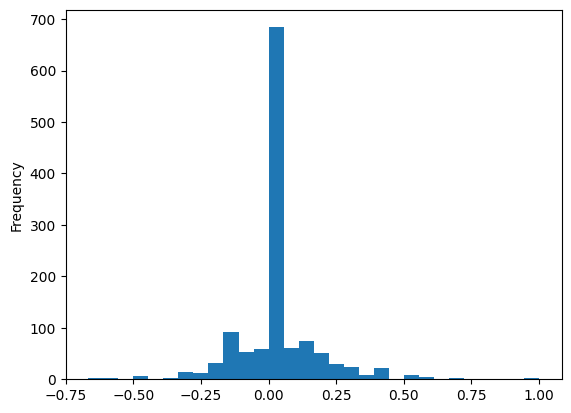

In [103]:
'''
Adding the series of sentiment scores onto our dataframe.

We also plot a histogram for the frequency of each sentiment score.  We
find that we have a lot of zeros, which is probably because many of the
words in our titles are not in the sentiment dictionary we established
earlier.

This is unfortunate and we can probably get better results by using other
libraries such as textblob or vader (which we do later).  Also makes sense
since the titles will often have player and team names in them and those 
are unlikely to be in any sentiment word score library.
'''

df['keyword_sentiment'] = get_sentiment(df)
sentiment_scores = df['keyword_sentiment']
_ = sentiment_scores.plot.hist(bins=30)

In [104]:
#Finding the mean, standard deviation, and median of our sentiment scores.
print('The mean sentiment score of the posts is: %.3f' %sentiment_scores.mean())
print('The standard deviation of the sentiment scores for the posts is: %.3f' %sentiment_scores.std())
print('The median of the sentiment scores for the posts is: %.3f' %sentiment_scores.median())

The mean sentiment score of the posts is: 0.021
The standard deviation of the sentiment scores for the posts is: 0.152
The median of the sentiment scores for the posts is: 0.000


In [105]:
'''
Sorting our sentiment score column to find the titles with the highest
and lowest sentiment scores. 
'''

df.sort_values(by='keyword_sentiment')[['title', 'keyword_sentiment']]

,title,keyword_sentiment
1011,Memphis Grizzlies scorekeeper posting fraudule...,-0.666667
833,[Highlight] Mitchell Robinson with a nasty put...,-0.625000
1015,"Shaq: ""I'm 47 years old. Lost two grandmothers...",-0.571429
1009,Draymond Green on last night's Capitol breach:...,-0.571429
1248,Slow Mo Kawhi steal,-0.500000
...,...,...
1153,LeBron buzzer beater to win it,0.666667
1156,[Highlight] Stephen Curry legendary run to end...,0.687500
920,Super rough/hot season start,0.750000
1057,Board Man celebrates,1.000000


In [106]:
'''
Here we show the full title of each of the bottom five titles with
the lowest sentiment score.  Reading these titles makes sense.  

(I would also be interested to see if the lowest sentiment score, 
the Memphis Grizzlies one, has very controversial comments.  
I remember that post being very very controversial and getting 
some national media attention.)
'''

df.sort_values(by='keyword_sentiment')['title'].to_list()[:10]

['Memphis Grizzlies scorekeeper posting fraudulent numbers',
 '[Highlight] Mitchell Robinson with a nasty putback slam',
 'Shaq: "I\'m 47 years old. Lost two grandmothers. Lost a Sarge. Lost my sister. And now, I lost a little brother."',
 'Draymond Green on last night\'s Capitol breach: "They\'re not fucking protesters, they fucking terrorists."',
 'Slow Mo Kawhi steal',
 'Worst playoff performances from a winner?',
 "[Highlight] Cooper Flagg's rejection",
 '[Highlight] Gradey Dick and Anthony Black jersey swap',
 'LeBron with the ridiculous and 1',
 '[Highlight] Grady Dick showing his skills and finish']

In [107]:
#Here are the top five titles with the highest sentiment score.
df.sort_values(by='keyword_sentiment', ascending=False)['title'].to_list()[:10]

['Best 5 healthy East players',
 'Board Man celebrates',
 'Super rough/hot season start',
 '[Highlight] Stephen Curry legendary run to end any France hope and win USA the gold medal',
 'LeBron buzzer beater to win it',
 'jersey sizing help',
 "[Highlight] Victor Wembanyama's incredible length",
 '[NBA] Best Quotes, Funny Moments & More From NBA Media Day 2025',
 'Amazing shooters that sucked at everything else?',
 '[Highlight] Giddey wins it from half court!']

In [108]:
#!conda install -c conda-forge textblob vadersentiment -y

# Optional Stuff

In [109]:
'''
Here we create two function that take in a text (string) and return a 
sentiment or subjectivity score.  The first one returns a sentiment score
while the second one returns a subjectivity score.
'''

from textblob import TextBlob

def get_tb_sentiment(text):
    tb = TextBlob(text)
    return tb.sentiment[0]

def get_tb_subjectivity(text):
    tb = TextBlob(text)
    return tb.sentiment[1]

df['tb_sentiment'] = df['title'].apply(get_tb_sentiment)
tb_sentiment = df['tb_sentiment']

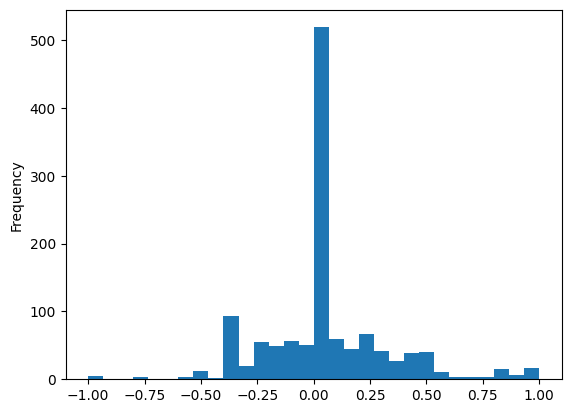

In [110]:
'''
Histogram of the sentiment scores for each title using TextBlob.  We see
that this histogram is more spread out which is better cause it means
that less words are not being analyze and simply given a score of zero.
'''

_ = tb_sentiment.plot.hist(bins=30)

In [111]:
'''
Our standard deviation has increased by about 0.13, which confirms that
TextBlob is working better.
'''

print('The mean sentiment score of the posts is: %.3f' %tb_sentiment.mean())
print('The standard deviation of the sentiment scores for the posts is: %.3f' %tb_sentiment.std())
print('The median of the sentiment scores for the posts is: %.3f' %tb_sentiment.median())

The mean sentiment score of the posts is: 0.038
The standard deviation of the sentiment scores for the posts is: 0.287
The median of the sentiment scores for the posts is: 0.000


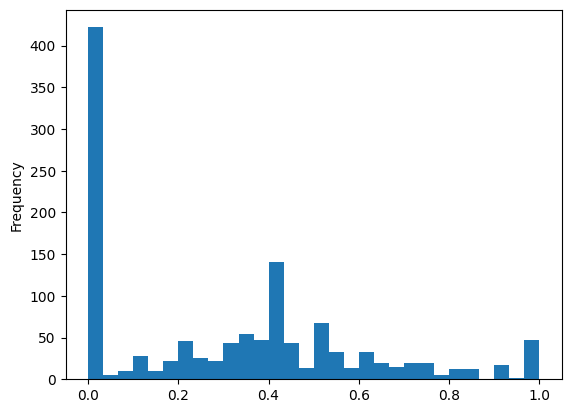

In [112]:
'''
Here we show a histogram of the subjectivity score frequency for all of
the titels.  Most of them are showing to be objective.  This is sort of 
surprising to me since sports overall is a subjective topic.

A possible reason for the numerous objective posts come from the many
highlight posts, which simply state what happens in the highlight.  Many
subreddit guidelines for r_nba are also strict on how subjective you can 
be in your post's titles.
'''

df['tb_sentiment'] = df['title'].apply(get_tb_subjectivity)
tb_sentiment = df['tb_sentiment']
_ = tb_sentiment.plot.hist(bins=30)

In [113]:
#Now we use the vader package to analyze sentiment scores.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df['post_compound'] = [analyzer.polarity_scores(i)['compound'] for i in df['title']]
compound = df['post_compound']

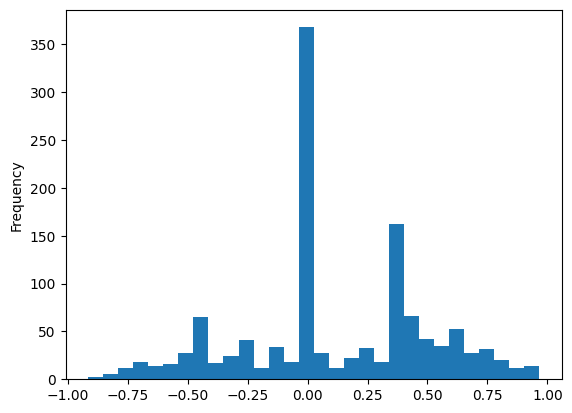

In [114]:
#Sentiment score frequency distribution of post's titles.
_ = compound.plot.hist(bins=30)

In [115]:
'''
Once again, our standard deviation went up by about 0.11, which shows
that vader is an imporvement over textblob.
'''

print('The mean sentiment score of the posts is: %.3f' %compound.mean())
print('The standard deviation of the sentiment scores for the posts is: %.3f' %compound.std())
print('The median of the sentiment scores for the posts is: %.3f' %compound.median())

The mean sentiment score of the posts is: 0.112
The standard deviation of the sentiment scores for the posts is: 0.390
The median of the sentiment scores for the posts is: 0.000


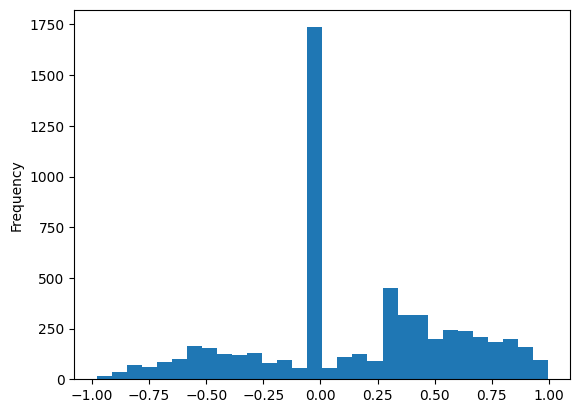

In [116]:
'''
Getting the sentiment values for all the comments from each post.
We are using Vader because it seems to have the highest std which means
that it has a more words in its library that have sentiment scores.

There seems to be more positive comments than negative.
'''

df_com['comment_compound'] = [analyzer.polarity_scores(i)['compound'] for i in df_com['comment']]
compound = df_com['comment_compound']
_ = compound.plot.hist(bins=30)

In [117]:
#Mean, std, and median for the distribution of comment sentiment.
print('The mean sentiment score of the posts is: %.3f' %compound.mean())
print('The standard deviation of the sentiment scores for the posts is: %.3f' %compound.std())
print('The median of the sentiment scores for the posts is: %.3f' %compound.median())

The mean sentiment score of the posts is: 0.154
The standard deviation of the sentiment scores for the posts is: 0.435
The median of the sentiment scores for the posts is: 0.000


In [118]:
'''
Below we find the avearge sentiment for each posts by looking at their
comments.  We will then compare each score to the score of the title
of the post's sentiment.
'''

avg_com_sent = df_com.groupby('post id')['comment_compound'].mean() 

In [119]:
'''
Here we add on the average sentiment score for the comments of each post
by merging that series onto the post's dataframe on the post id.
'''

df_total = pd.merge(df, avg_com_sent, on='post id')
df_total

,post id,title,link,author,n_comments,score,text,keyword_sentiment,tb_sentiment,post_compound,comment_compound
0,1o6msn4,Daily Discussion Thread + Game Thread Index,/r/nba/comments/1o6msn4/daily_discussion_threa...,NBA_MOD,1,2,"# Game Threads Index (October 14, 2025):\n\n|T...",0.000000,0.200000,0.0000,0.88680
1,1o6cdbe,[SERIOUS NEXT DAY THREAD] Post-Game Discussion...,/r/nba/comments/1o6cdbe/serious_next_day_threa...,NBA_MOD,6,7,"Here is a place to have in depth, x's and o's,...",0.000000,0.333333,-0.2577,-0.09448
2,1o6peb2,The Celtics coaches just played a pickup game ...,/r/nba/comments/1o6peb2/the_celtics_coaches_ju...,Brady331,144,2439,video via Taylor Snow\n\nMore context via Noa ...,0.187500,0.400000,0.7269,-0.02954
3,1o6o619,Joe Mazzulla does not like the NBA preseason: ...,/r/nba/comments/1o6o619/joe_mazzulla_does_not_...,Mission_Pay_3373,293,2329,,-0.047619,0.650000,-0.6007,0.09980
4,1o6met7,Giannis Antetokounmpo says he wants to finish ...,/r/nba/comments/1o6met7/giannis_antetokounmpo_...,Pickleskennedy1,195,1652,https://bleacherreport.com/articles/25260547-g...,0.000000,0.100000,0.2023,0.34814
...,...,...,...,...,...,...,...,...,...,...,...
1240,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,,0.133333,0.650000,0.6597,0.32720
1241,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,,0.000000,0.000000,0.0000,0.52834
1242,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,,-0.058824,0.550000,0.2808,-0.18674
1243,bt37ig,[Post Game Thread] The Toronto Raptors (4-2) d...,/r/nba/comments/bt37ig/post_game_thread_the_to...,nick168,7642,30270,**[](/MIL) MIL**|**Min**|**FG**|**FT**|**3PT**...,-0.080000,0.366667,-0.4588,0.19680


In [120]:
'''
Now we find the difference between each title sentiment and average
comment sentiment.
Below are the five posts with the biggest difference between the title's
sentiment and the comment's sentiment.
Interestingly, it seems that in all of these posts, the title had a 
negative sentiment while the comments had a positive sentiment.
'''

df_total['delta_sent'] = abs(df_total['post_compound']-df_total['comment_compound'])
df_total.sort_values(by='delta_sent', ascending=False)[['post_compound', 'comment_compound']][:5]

,post_compound,comment_compound
631,-0.7003,0.69916
823,-0.8126,0.43918
196,-0.7783,0.46328
1087,-0.9151,0.25216
156,-0.4588,0.70540


In [121]:
'''
Here are the full titles of each of the five posts with the largest sentiemnt 
delta.
'''

df_total.sort_values(by='delta_sent', ascending=False)['title'][:5].to_list()

['Former NBA player John Amaechi describes how he lost all his money in Lehman Brothers collapse and being broke while officially promoting London 2012 Olympics',
 'Which team do you think will abuse it the the most if Clippers get zero to light punishment for cap circumvention',
 '[Highlights] Johnny Furphy with the nasty poster dunk on Malevy Leons, and the steal and fastbreak assist to Quenton Jackson for the dunk (with replays). Ajay Mitchell banks in the And-1 at the other end. Multi-broadcast - EN1|EN2|EN3|EN4.',
 'Tim Hardaway apologizes for past anti-gay comments: "I grew up in a church and that’s the way churches were. Don’t talk to them, don’t mess with them, leave them alone. It was so wrong of me and people have suffered. I had to grow up and really do some soul-searching. What I said was just hurtful."',
 '[Post Game Thread] The Milwaukee Bucks (3-0) defeat the Chicago Bulls (2-1), 127-121.']

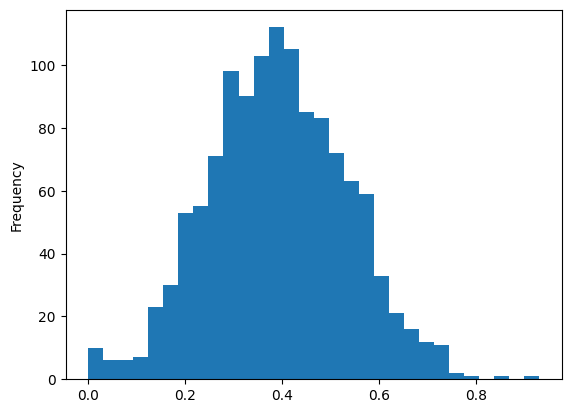

In [122]:
'''
We can also go back to our df_com and look at the posts with the widest
range of sentiment values in their comments (controversial posts).
We can do this by either finding the highest range or the highest std.
'''

std_com_sent = df_com.groupby('post id')['comment_compound'].std()
range_com_sent = df_com.groupby('post id')['comment_compound'].agg(
    lambda x: x.max() - x.min())
_ = std_com_sent.plot.hist(bins=30)

<Axes: ylabel='Frequency'>

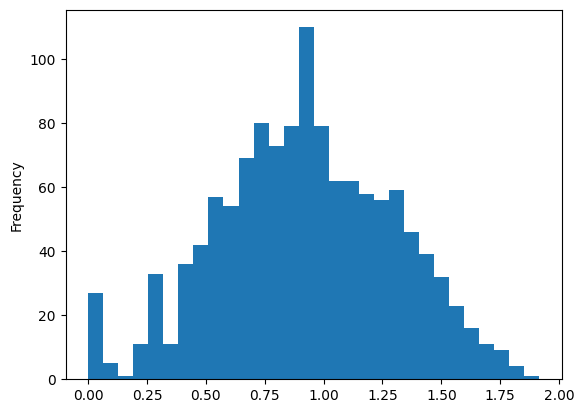

In [123]:
range_com_sent.plot.hist(bins=30)

In [124]:
df_total = pd.merge(df_total, std_com_sent, on='post id')
df_total = pd.merge(df_total, range_com_sent, on='post id')
df_total.rename(columns={'comment_compound_y': 'comment_std',
                         'comment_compound': 'comment_range'},
               inplace=True)
df_total

,post id,title,link,author,n_comments,score,text,keyword_sentiment,tb_sentiment,post_compound,comment_compound_x,delta_sent,comment_std,comment_range
0,1o6msn4,Daily Discussion Thread + Game Thread Index,/r/nba/comments/1o6msn4/daily_discussion_threa...,NBA_MOD,1,2,"# Game Threads Index (October 14, 2025):\n\n|T...",0.000000,0.200000,0.0000,0.88680,0.88680,NaN,0.0000
1,1o6cdbe,[SERIOUS NEXT DAY THREAD] Post-Game Discussion...,/r/nba/comments/1o6cdbe/serious_next_day_threa...,NBA_MOD,6,7,"Here is a place to have in depth, x's and o's,...",0.000000,0.333333,-0.2577,-0.09448,0.16322,0.197158,0.4466
2,1o6peb2,The Celtics coaches just played a pickup game ...,/r/nba/comments/1o6peb2/the_celtics_coaches_ju...,Brady331,144,2439,video via Taylor Snow\n\nMore context via Noa ...,0.187500,0.400000,0.7269,-0.02954,0.75644,0.537221,1.4443
3,1o6o619,Joe Mazzulla does not like the NBA preseason: ...,/r/nba/comments/1o6o619/joe_mazzulla_does_not_...,Mission_Pay_3373,293,2329,,-0.047619,0.650000,-0.6007,0.09980,0.70050,0.585681,1.3999
4,1o6met7,Giannis Antetokounmpo says he wants to finish ...,/r/nba/comments/1o6met7/giannis_antetokounmpo_...,Pickleskennedy1,195,1652,https://bleacherreport.com/articles/25260547-g...,0.000000,0.100000,0.2023,0.34814,0.14584,0.410708,1.0100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,,0.133333,0.650000,0.6597,0.32720,0.33250,0.254949,0.6369
1241,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,,0.000000,0.000000,0.0000,0.52834,0.52834,0.333183,0.8531
1242,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,,-0.058824,0.550000,0.2808,-0.18674,0.46754,0.930305,1.9152
1243,bt37ig,[Post Game Thread] The Toronto Raptors (4-2) d...,/r/nba/comments/bt37ig/post_game_thread_the_to...,nick168,7642,30270,**[](/MIL) MIL**|**Min**|**FG**|**FT**|**3PT**...,-0.080000,0.366667,-0.4588,0.19680,0.65560,0.282608,0.6124


In [125]:
'''
Getting the five titles that were the most controversial accoring
to standard deviation and range among the comments.  We see
some similarities between the results, which makes sense.
'''

df_total.sort_values(by='comment_std', ascending=False)['title'][:5].to_list()

['Lakers coach JJ Redick with a lot of perspective on losing his rental home in Pacific Palisades: “I don’t want people to feel sorry for me and my family. We’re gonna be alright. There are people that, because of some political issues and some insurance issues, are not gonna be alright.”',
 'Zion Williamson in the win against the Australian National Basketball League’s (NBL) Melbourne United:  15 points, 2 rebounds, 5 assists, 2 steals, 2 turnovers, 2 personal fouls on a +\\- of +10 in 15 minutes.',
 '[Post Game Thread] The New York Knicks (2-0) defeat the Philadelphia 76ers (0-2), 113-101.',
 'Lonzo Ball released more songs on spotify (21), than he made free throws last season (20).',
 'In the Points of Emphasis Rules for the upcoming season: Offensive players are allowed to push a defensive player away, but if a defender initiates contact by bumping the offensive player, it will be called a foul on the defense.']

In [126]:
df_total.sort_values(by='comment_range', ascending=False)['title'][:5].to_list()

['Lakers coach JJ Redick with a lot of perspective on losing his rental home in Pacific Palisades: “I don’t want people to feel sorry for me and my family. We’re gonna be alright. There are people that, because of some political issues and some insurance issues, are not gonna be alright.”',
 "Cooper Flagg's place on a chart of the Top 250 NCAA players last year and their ages, 1st in BPM and the 2nd youngest. (Source: Jxmyhighroller - Is Cooper Flagg Really Worth The Hype?)",
 'Tim Hardaway apologizes for past anti-gay comments: "I grew up in a church and that’s the way churches were. Don’t talk to them, don’t mess with them, leave them alone. It was so wrong of me and people have suffered. I had to grow up and really do some soul-searching. What I said was just hurtful."',
 'In the Points of Emphasis Rules for the upcoming season: Offensive players are allowed to push a defensive player away, but if a defender initiates contact by bumping the offensive player, it will be called a foul

In [127]:
'''
We can also look at the most common words among negative and positive
posts.  First, let's get and save the 100 most negative and positive
posts.
'''

negative_titles = df_total.sort_values(by='post_compound')['title'][:100].to_list()
positive_titles = df_total.sort_values(by='post_compound', ascending=False)['title'][:100].to_list()

In [128]:
'''
Now let's get the most common words from these two lists.
Below are the 10 most common words among negative titles along with their
frequency.
'''

from collections import Counter
from nltk.corpus import stopwords

#Tokenizing the words from our list of titles.
title_words = []
for title in negative_titles:
    words = title.lower().split()
    stop_words = stopwords.words('english')
    for w in words:
        if w not in stop_words:
            title_words.append(w)

#Counting the frequency of each word
word_counts = Counter(title_words)

#Converting those frequencies into a dataframe so that we can visualize data
df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
df = df.sort_values(by='frequency', ascending=False)
print(df.head(10))
#_ = df_words.sort_values(by='0', axis=1, ascending=False)[:10].plot.bar()

            word  frequency
78           nba         12
319         game         10
160  [highlight]          8
402         luka          7
13         don’t          7
76       players          7
153         lost          7
25          said          6
178        james          6
177       lebron          6


In [129]:
'''
Now we do the same for the positive titles.
'''

#Tokenizing the words from our list of titles.
title_words = []
for title in positive_titles:
    words = title.lower().split()
    stop_words = stopwords.words('english')
    for w in words:
        if w not in stop_words:
            title_words.append(w)

#Counting the frequency of each word
word_counts = Counter(title_words)

#Converting those frequencies into a dataframe so that we can visualize data
df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
df = df.sort_values(by='frequency', ascending=False)
print(df.head(10))

            word  frequency
229  [highlight]         28
5            win         20
83          like         16
92         think         14
103         play         12
61          best         12
43          game         12
421          nba         10
132          get          9
24          luka          9


In [130]:
'''
Let's do some topic modeling with our post titles.  We will try to group
the titles into different categories using gensim and its related
packages.

First we import all the required packages and modules that we need.
We also get our stopwords.
'''

#!pip install gensim nltk spacy
#!pip install gensim nltk spacy pyLDAvis
import re
from pprint import pprint
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
import spacy
import pyLDAvis
import pyLDAvis.gensim 
import matplotlib.pyplot as plt

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])
df = pd.read_sql_query('SELECT * from posts;', nba)

In [131]:
'''
Here we create a function that takes in a list of sentences and cleans
it up by tokenizing the text.  We use this function on all the titles
in our dataframe and save it as a list of lists in the variable "data".
'''

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), 
                                             deacc=True))

titles = df['title'].to_list()
data = list(sent_to_words(titles))
data[:2]

[['daily', 'discussion', 'thread', 'game', 'thread', 'index'],
 ['serious', 'next', 'day', 'thread', 'post', 'game', 'discussion', 'october']]

In [132]:
'''
Now we want to collect bigrams from all of the titles.
'''

bigram = gensim.models.Phrases(data, min_count=5, threshold=50)
bigram = gensim.models.phrases.Phraser(bigram)
bigram[data[0]]

['daily_discussion', 'thread', 'game_thread', 'index']

In [133]:
'''
Here we create two function to tokenize our data and them get a list of
common bigras from that data.
'''

#Function removes stopwords from a text
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]

#This function converts a text into a list of common bigrams
def make_bigrams(texts):
    return [bigram[doc] for doc in texts]

data = remove_stopwords(data)
data = make_bigrams(data)
data[:5]

[['daily_discussion', 'thread', 'game_thread', 'index'],
 ['serious_next', 'day', 'thread', 'post_game', 'discussion_october'],
 ['celtics',
  'coaches',
  'played',
  'pickup',
  'game',
  'vs',
  'celtics',
  'media',
  'coaches'],
 ['joe_mazzulla',
  'like',
  'nba',
  'preseason',
  'hate',
  'preseason',
  'games',
  'practice',
  'month',
  'straight'],
 ['giannis_antetokounmpo',
  'says',
  'wants',
  'finish',
  'career',
  'playing',
  'greece',
  'plans',
  'move']]

In [134]:
'''
Now we take our data and create a key for each title.  The first number
in the tuple is the word_id and the second number is the word_frequency.

So looking at our first posts title above, which has four words (from 
cleaned data) "thread, game, thread, index".  So below we see that we 
have two words with a frequency of 1 (game, index) and one words with a 
frequency of two (thread)
'''

id2word = corpora.Dictionary(data)
texts = data
corpus = [id2word.doc2bow(text) for text in texts]
print(corpus[:5])

[[(0, 1), (1, 1), (2, 1), (3, 1)], [(3, 1), (4, 1), (5, 1), (6, 1), (7, 1)], [(8, 2), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1)], [(15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 2), (23, 1)], [(24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1)]]


In [135]:
'''
Lastly, we create the lda model.  This model takes our corpus above with
the keyed words for each title and automatically creates topics.
We first run through different amount of topics to see which 
returns the highest coherence score, which we will then use for our
final model.
'''
max_coherence = 0
num_topics = 0
for i in range(1, 20):
    lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                               id2word=id2word,
                                               num_topics=i, 
                                               random_state=100,
                                               update_every=1,
                                               chunksize=100,
                                               passes=10,
                                               alpha='auto',
                                               per_word_topics=True)

    coherence_model_lda = CoherenceModel(model=lda_model, texts=data, dictionary=id2word, coherence='c_v')
    coherence_lda = coherence_model_lda.get_coherence()
    print('\nCoherence Score: ', coherence_lda, i)
    if coherence_lda > max_coherence:
        max_coherence = coherence_lda
        num_topics = i


Coherence Score:  0.35849123112077474 1

Coherence Score:  0.3460131631538193 2

Coherence Score:  0.37535476752393987 3

Coherence Score:  0.4347284786429064 4

Coherence Score:  0.4551356412228976 5

Coherence Score:  0.46620354710070516 6

Coherence Score:  0.5026112048064586 7

Coherence Score:  0.5108435703911933 8

Coherence Score:  0.49106444984115666 9

Coherence Score:  0.5349329824311605 10

Coherence Score:  0.525436115531314 11

Coherence Score:  0.5358929744278649 12

Coherence Score:  0.4991672230653741 13

Coherence Score:  0.4881881883333599 14

Coherence Score:  0.446360789082245 15

Coherence Score:  0.43281561020551546 16

Coherence Score:  0.45088470300885103 17

Coherence Score:  0.4538910593151189 18

Coherence Score:  0.4327254222071898 19


In [136]:
'''
Each number represents the unique topic.  The words (along with their weights)
represent the words most associated with the said topic.  The weights tell
how important each word to that specific topic.
'''

lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                               id2word=id2word,
                                               num_topics=num_topics, 
                                               random_state=100,
                                               update_every=1,
                                               chunksize=100,
                                               passes=10,
                                               alpha='auto',
                                               per_word_topics=True)
pprint(lda_model.print_topics())

[(0,
  '0.088*"lakers" + 0.047*"get" + 0.036*"league" + 0.032*"years" + '
  '0.030*"eliminated" + 0.029*"today" + 0.025*"championship_contention" + '
  '0.017*"jokic" + 0.015*"defense" + 0.013*"called"'),
 (1,
  '0.035*"like" + 0.033*"thread" + 0.031*"going" + 0.029*"warriors" + '
  '0.025*"coach" + 0.025*"post_game" + 0.024*"defeat" + 0.022*"spurs" + '
  '0.021*"popovich" + 0.020*"teams"'),
 (2,
  '0.080*"game" + 0.036*"win" + 0.029*"one" + 0.020*"back" + 0.020*"new" + '
  '0.017*"highlight" + 0.016*"us" + 0.016*"baby" + 0.016*"finals" + '
  '0.014*"fans"'),
 (3,
  '0.052*"lebron" + 0.051*"highlight" + 0.019*"said" + 0.019*"throws" + '
  '0.019*"best" + 0.016*"curry" + 0.016*"court" + 0.016*"every" + 0.016*"look" '
  '+ 0.012*"wins"'),
 (4,
  '0.036*"hits" + 0.031*"better" + 0.027*"age" + 0.025*"james" + '
  '0.022*"anthony" + 0.016*"harden" + 0.016*"prime" + 0.013*"winning" + '
  '0.013*"guys" + 0.013*"scores"'),
 (5,
  '0.062*"nba" + 0.021*"charania" + 0.020*"first" + 0.019*"time" +

In [137]:
'''
Lastly lastly, let's visualize the topics!

Each bubble represents a unique topic.  A good LDA model will
limit the amount of overlap between bubbles, while also having
a good distribution among the four quadrants.  

The bar chart on the right shows how "salient" each word is to
the topic highlighted.  The blue in the hart represents how 
salient that word is to the overall data, and the amount filled
by red is how salient the word is to the specific topic you
are on.

We can see that words such as game, highlight, nba, thread, lakers,
team, and so on are very frequent in the overall data.  If we want
to try to infere what some of the topics may be, we can look at the
frequency of words in that topic.  For example, topic 1 has terms such
as Charania, Wojnarowski, team, and trade.  This topic is probably
all the posts that are about trades and free agency signings!

This model seems to do all right.  It would be tough to get
great results considering the limiting amount of data that we
have.
'''

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.394988  0.049543       1        1  24.953548
2     -0.041079  0.185855       2        1  10.608008
3     -0.075321  0.126717       3        1  10.053386
11    -0.070323  0.097384       4        1   9.583383
6     -0.007844 -0.123579       5        1   9.327854
1     -0.014142 -0.193317       6        1   8.321784
8     -0.058493  0.087025       7        1   7.965475
0     -0.018976 -0.057392       8        1   4.939937
9     -0.037256 -0.047760       9        1   4.627588
10    -0.024082 -0.052843      10        1   4.169848
4     -0.024961 -0.037650      11        1   3.194818
7     -0.022513 -0.033985      12        1   2.254370, topic_info=           Term        Freq       Total Category  logprob  loglift
20          nba  203.000000  203.000000  Default  30.0000  30.0000
10         game  129.000000  129.000000  Default  29.0000  29.0000
109   highlight  207.000000  207.000000  Default  28.0000  28.0000
524      lakers   57.000000   57.000000  Default  27.0000  27.0000
64       lebron   69.000000   69.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
364         ecf    1.716644    2.517900  Topic12  -5.1457   3.4092
1674         ts    1.612019    2.413268  Topic12  -5.2086   3.3888
1251     report    1.572795    2.374053  Topic12  -5.2332   3.3806
1620     splits    1.555225    2.356486  Topic12  -5.2445   3.3767
144    coaching    1.491404    2.292672  Topic12  -5.2864   3.3623

[410 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
612       7  0.897416  aaron_gordon
2102     11  0.865507       acquire
664       3  0.945897   adam_silver
117      11  0.903433           age
2406     11  0.860273            al
...     ...       ...           ...
1754     12  0.755339        wright
3518      7  0.931060         wrong
197       1  0.989130          year
141       8  0.982344         years
135      11  0.803486         young

[390 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 3, 4, 12, 7, 2, 9, 1, 10, 11, 5, 8])

In [138]:
'''
We can also do this entire process again but with the comments
as our data.  Below is a function that goes through each step and
returns the final visualization from above.  We will use the comments
as our data this time.
'''

def topics(data):
    stop_words = stopwords.words('english')
    stop_words.extend(['from', 'subject', 're', 'edu', 'use'])
    
    data = remove_stopwords(data)
    data = make_bigrams(data)

    id2word = corpora.Dictionary(data)
    texts = data
    corpus = [id2word.doc2bow(text) for text in texts]

    max_coherence = 0
    num_topics = 0
    for i in range(1, 20):
        lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                                   id2word=id2word,
                                                   num_topics=i, 
                                                   random_state=100,
                                                   update_every=1,
                                                   chunksize=100,
                                                   passes=10,
                                                   alpha='auto',
                                                   per_word_topics=True)
    
        coherence_model_lda = CoherenceModel(model=lda_model, texts=data, dictionary=id2word, coherence='c_v')
        coherence_lda = coherence_model_lda.get_coherence()
        if coherence_lda > max_coherence:
            max_coherence = coherence_lda
            num_topics = i

    lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                               id2word=id2word,
                                               num_topics=num_topics, 
                                               random_state=100,
                                               update_every=1,
                                               chunksize=100,
                                               passes=10,
                                               alpha='auto',
                                               per_word_topics=True)

    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)

    return vis

comments = df_com['comment'].to_list()
data = list(sent_to_words(comments))
topics(data)

PreparedData(topic_coordinates=              x    y  topics  cluster      Freq
topic                                          
0      0.193894  0.0       1        1  81.04348
1     -0.193894  0.0       2        1  18.95652, topic_info=           Term        Freq       Total Category  logprob  loglift
35          nba  512.000000  512.000000  Default  30.0000  30.0000
2428    deleted  236.000000  236.000000  Default  29.0000  29.0000
186   community  197.000000  197.000000  Default  28.0000  28.0000
93    questions  184.000000  184.000000  Default  27.0000  27.0000
24        https  172.000000  172.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
35          nba  262.188852  512.777321   Topic2  -3.8855   0.9922
8587     status   50.569644   53.200403   Topic2  -5.5312   1.6123
588        feel   88.639255  139.753893   Topic2  -4.9700   1.2077
9219      cries   50.926467   56.797681   Topic2  -5.5242   1.5539
688        free   50.640915   81.127967   Topic2  -5.5298   1.1918

[103 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
70        2  0.997777     action
219       1  0.998209       also
219       2  0.005907       also
477       2  0.995654  alternate
478       2  0.996231     angles
...     ...       ...        ...
149       2  0.002894      would
67        2  0.987363        www
204       1  0.998921       year
204       2  0.004440       year
536       1  0.996918      years

[113 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2])

# Summary

Firstly, we read in our data from last week's SQL databases (both the posts and the comments).  Next, we read in the AFINN corpus to get a list of sentiment scores for common english words and saved it to a dictionary.  We will use these scores moving forward in the beginning of our sentiment analysis.

We then found the sentiment score of each title, added it as a column to our dataframe, and then graphed its distribution.  The distribution shows a heavy amount of posts with zero (or neutral) sentiment.  This also could be happening since if a word is not in the AFINN dictionary, then we give it a score of zero by default, and the AFINN dictionary is not the best sentiment score keeper (we will look at better ones later in the assignment).  We also found the mean (0.021), standard deviation (0.152), and the median (0) of the sentiment scores.  Some of the titles with the lowest and highest sentiment scores make sense given the context of the post.

In the optional section, we did the same process but with TextBlob and Vader as our source for word sentiment scores.  Both packages still showed many of the titles having a neutral sentiment score, but both also had higher standard deviation (0.287 for TextBlob and 0.390 for Vader), showing that the sentiment scores are more spread out.  This indicates that these two packages are more sensitive to the actual sentiment of each word, and therefore each post.

Next, we looked at the sentiment scores for our other SQL data, the comments.  We found the sentiment score for each comment (using Vader) and then merged the average sentiment score for each post onto a new dataframe that includes all of our posts and their sentiment scores up to this point.  With this new dataframe, we can see the sentiment scores of each post's title along with its average comment sentiment score.  This allows us to do things such as finding the biggest disparity in sentiment socres, or delta, between the post's title and the post's comments.  Looking at those results, we see some posts that make sense.  One post is about Tim Hardaway apologizing for past anit-gay comments, which would definitely be a controversial post.  Interestingly, all of the most controversial posts have a negative title score while having a positive comment score.  We could also find some other controversial posts by looking at the biggest disparity between comment sentiment scores within a single post.  The returned some interesting results, such as a post about the league changing some of its officiating, a topic that is very controversial among die-hard fans.  Lastly in this section, we also found the most common words associated with highest and lowest post sentiment scores.  Some of the most common words from negative posts include "don't", "lost", or "luka".  Some of the most common words among positive posts include "win", "best", and "highlight".

For the final section of this week's homework assignemnt, we use genism to group our titles into topics.  Firstly, we remove all the stop_words (words that are extremely common and add little value) from our post's titles.  Then we put all of our words into a list of lists, with each list being a different post's title.  Then we use gensim's bigram model maker, which takes all the words from each title and combines them if they are commonly found together to form a bigram.  So, for example, in the first title, the model puts "daily" and "discussion" together into "daily_discussion" and "game" and "thread" together into "game_thread".  These two bigrams are extremly common.  Every day there is a daily_discussion post and every game has a game_thread tag attributed to it.  At first this fucntion created very few bigrams, so I decided to lower the threshold of creating a bigram to 50 insteaad of 100.
Next we use the corpora dictionary function to convert all of our words to a key of tuples, with the first number representing that word's, or sometimes bigram's, unique ID, and the second number represents how many times it appears in that title.  The last step to get our topics is to use gensim's ldamodel function.  It will automatically create topics based on the data given.  The only parameter that we will try to optimize is the number of topics created.  We can create the model many times and find which one returns the highest coherence score to get the number of ideal topics.  After doing that, we graph our results using pyLDAvis.  The results for the post's titles shows about 12 topics, many of which are overlapping, which is not ideal.  One thing we could try in the future is shortening the amount of posts and tuning another parameter in our model to maintain a higher coherence score.  It is not always apparent what a topic is in our model, but the best way to find out is to look at the words most associated with that topic, which we can do by looking at the bar graph to the right.  For example, it is very likely that topic 1 is about trades and free agency signings, as it is the only topic with words "charnia" and "worjanowski" in it, plus other keywords such as "trade" or "sources_tell" (hey a bigram!).  Charnia and Worjanowski are the two main reporters that break all new trades and free agency signings.
Lastly, we can repeat all of these steps but with the comments as our intial data.  Doing so returns the opposite problem of having to little amount of topics.  Again, future iterations of the homework could include trying to tune other parameters so that we could increase the number of topics.

Overall, sentiment scores are a great way to get feedback on what is being posted or said in any social media forum, which we can then use as a buisness to make better, and more informed decisions.